In [9]:
import json
from pathlib import Path
from collections import Counter

TACO_ROOT = Path("../data/raw/")
ANNOTATIONS_PATH = TACO_ROOT / "annotations.json"

with open(ANNOTATIONS_PATH, "r", encoding="utf-8") as f:
    annotations = json.load(f)

annotations.keys()

dict_keys(['info', 'images', 'annotations', 'scene_annotations', 'licenses', 'categories', 'scene_categories'])

In [4]:
num_images = len(annotations["images"])
num_annotations = len(annotations["annotations"])
num_categories = len(annotations["categories"])

print("Images:", num_images)
print("Annotations:", num_annotations)
print("Categories:", num_categories)

Images: 1500
Annotations: 4784
Categories: 60


In [7]:
categories = annotations["categories"]

for cat in categories:
    print(cat["id"], cat["name"])

0 Aluminium foil
1 Battery
2 Aluminium blister pack
3 Carded blister pack
4 Other plastic bottle
5 Clear plastic bottle
6 Glass bottle
7 Plastic bottle cap
8 Metal bottle cap
9 Broken glass
10 Food Can
11 Aerosol
12 Drink can
13 Toilet tube
14 Other carton
15 Egg carton
16 Drink carton
17 Corrugated carton
18 Meal carton
19 Pizza box
20 Paper cup
21 Disposable plastic cup
22 Foam cup
23 Glass cup
24 Other plastic cup
25 Food waste
26 Glass jar
27 Plastic lid
28 Metal lid
29 Other plastic
30 Magazine paper
31 Tissues
32 Wrapping paper
33 Normal paper
34 Paper bag
35 Plastified paper bag
36 Plastic film
37 Six pack rings
38 Garbage bag
39 Other plastic wrapper
40 Single-use carrier bag
41 Polypropylene bag
42 Crisp packet
43 Spread tub
44 Tupperware
45 Disposable food container
46 Foam food container
47 Other plastic container
48 Plastic glooves
49 Plastic utensils
50 Pop tab
51 Rope & strings
52 Scrap metal
53 Shoe
54 Squeezable tube
55 Plastic straw
56 Paper straw
57 Styrofoam piece
58

In [ ]:
import pandas as pd

categories_df = pd.DataFrame(categories)
categories_df.head()

,supercategory,id,name
0,Aluminium foil,0,Aluminium foil
1,Battery,1,Battery
2,Blister pack,2,Aluminium blister pack
3,Blister pack,3,Carded blister pack
4,Bottle,4,Other plastic bottle


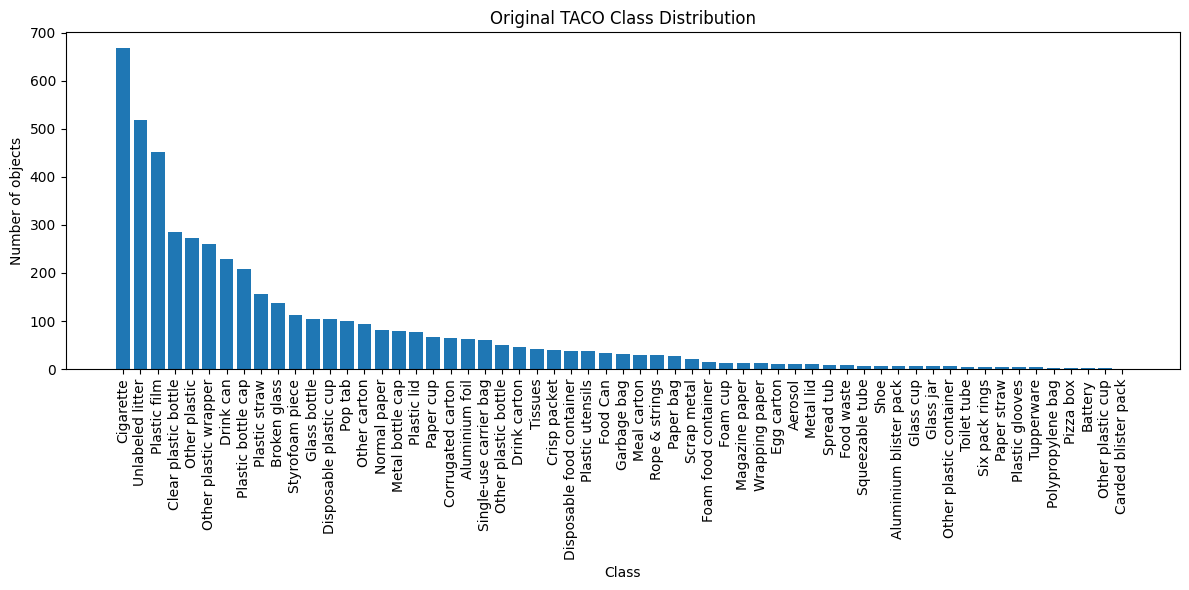

In [12]:
import matplotlib.pyplot as plt

category_id_to_name = {
    cat["id"]: cat["name"]
    for cat in annotations["categories"]
}

original_class_counts = Counter(
    category_id_to_name[ann["category_id"]]
    for ann in annotations["annotations"]
)

original_df = pd.DataFrame(
    original_class_counts.items(),
    columns=["class_name", "count"]
).sort_values("count", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(original_df["class_name"], original_df["count"])
plt.xticks(rotation=90)
plt.title("Original TACO Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of objects")
plt.tight_layout()
plt.savefig("../results/original_class_distribution.png", dpi=200)
plt.show()